In [ ]:
%pip install torch torchvision tqdm numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\shwet\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import os
import numpy as np
from tqdm import tqdm

In [7]:
class singleRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(singleRNN, self).__init__()
        self.Wx = torch.randn(n_neurons, n_inputs)
        self.Wy = torch.randn(n_neurons, n_neurons)
        self.b = torch.zeros(n_neurons, 1)

    def forward(self, X0, X1):
        self.Y0 = torch.tanh(torch.mm(self.Wx, X0)+ self.b)
        self.Y1 = torch.tanh(torch.mm(self.Wy, self.Y0)) + torch.mm(self.Wx, X1) + self.b
        return self.Y0, self.Y1

In [9]:
N_INPUT=4
N_NEURONS=1
X0_batch=torch.tensor([[0,1,2,0], [3,4,5,0], [6,7,8,0], [9,0,1,0]], dtype=torch.float)
X1_batch=torch.tensor([[9,8,7,0], [0,0,0,0], [6,5,4,0], [3,1,2,0]], dtype=torch.float)
model = singleRNN(N_INPUT, N_NEURONS)
Y0, Y1 = model(X0_batch, X1_batch)

In [12]:
print(Y0)
print(Y1)

tensor([[1.0000, 0.9277, 0.9974, 0.0000]])
tensor([[6.3423, 3.7261, 4.5251, 0.0000]])


In [17]:
class BasicRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(BasicRNN, self).__init__()
        self.Wx = torch.randn(n_neurons, n_inputs)
        self.Wy = torch.randn(n_neurons, n_neurons)
        self.b = torch.zeros(n_neurons, 1)
    

    def forward(self, X0, X1):
        X0 = X0.t()
        X1 = X1.t()
        self.Y0 = torch.tanh(torch.mm(self.Wx, X0) + self.b)
        self.Y1 = torch.tanh(torch.mm(self.Wy, self.Y0) +
    torch.mm(self.Wx, X1) + self.b)
        
        return self.Y0, self.Y1

In [19]:
N_INPUTS = 3
N_NEURONS = 5
X0_batch=torch.tensor([[0,1,2], [3,4,5], [6,7,8], [9,0,1]], dtype=torch.float)
X1_batch=torch.tensor([[9,8,7], [0,0,0], [6,5,4], [3,1,2]], dtype=torch.float)
model = BasicRNN(N_INPUTS, N_NEURONS)
Y0, Y1= model(X0_batch, X1_batch)

In [26]:
rnn = nn.RNNCell(3, 5)
X_batch = torch.tensor([[[0,1,2], [3,4,5],
                        [6,7,8], [9,0,1]],
                        [[9,8,7], [0,0,0],
                         [6,5,4], [3,2,1]]],
                        dtype=torch.float)
hx = torch.randn(4, 5)
output=[]
for i in range(2):
    hx=rnn(X_batch[i], hx)
    output.append(hx)
print(output)

[tensor([[-0.0208, -0.6494, -0.3627, -0.0829,  0.5119],
        [-0.9789, -0.9675, -0.9511,  0.7902,  0.9172],
        [-0.9992, -0.9929, -0.9943,  0.9560,  0.9793],
        [-0.9999,  0.1079, -0.3124,  0.9914, -0.7913]],
       grad_fn=<TanhBackward0>), tensor([[-0.9988, -0.5987, -0.9705,  0.9558,  0.8500],
        [-0.8966, -0.8235, -0.8420,  0.2877,  0.8622],
        [-0.9978, -0.7701, -0.9686,  0.9360,  0.8754],
        [-0.9541, -0.1479, -0.6779,  0.8459,  0.3153]],
       grad_fn=<TanhBackward0>)]


In [2]:
BATCH_SIZE = 64

# list all transformations
transform = transforms.Compose(
    [transforms.ToTensor()])
# download and load training dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=0)
# download and load testing dataset
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=0)

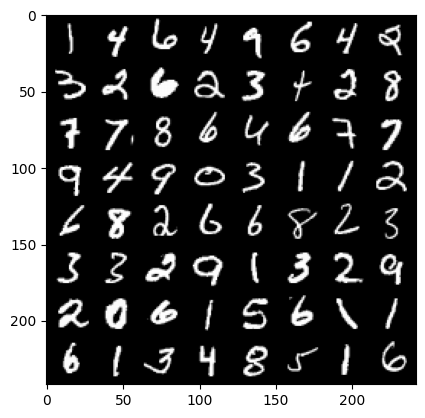

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
# get some random training images
data_iter = iter(trainloader)
images, labels = next(data_iter)
# show images
imshow(torchvision.utils.make_grid(images))

In [4]:
N_STEPS =28
N_INPUTS =28
N_NEURONS = 150
N_OUTPUTS = 10
N_EPHOCS =10

In [5]:
class ImageRNN(nn.Module):
    def __init__(self, batch_size, n_steps, n_inputs, n_neurons, n_outputs):
        super(ImageRNN, self).__init__()

        self.n_neurons = n_neurons
        self.batch_size = batch_size
        self.n_steps = n_steps
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs

        self.basic_rnn = nn.RNN(self.n_inputs, self.n_neurons)

        self.FC = nn.Linear(self.n_neurons, self.n_outputs)

    def init_hidden(self,):
        # (num_layers, batch_size, n_neurons)
        return (torch.zeros(1, self.batch_size, self.n_neurons))

    def forward(self, X):
        # transforms X to dimensions: n_steps X batch_size X n_inputs
        X = X.permute(1, 0, 2)
        self.batch_size = X.size(1)
        self.hidden = self.init_hidden()
        # lstm_out => n_steps, batch_size, n_neurons (hidden states for each time step)
        # self.hidden => 1, batch_size, n_neurons (final state from each lstm_out)
        lstm_out, self.hidden = self.basic_rnn(X, self.hidden)
        out = self.FC(self.hidden)
        return out.view(-1, self.n_outputs) # batch_size X n_output

In [6]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
logits = model(images.view(-1, 28,28))
print(logits[0:10])

tensor([[ 0.0066, -0.0315,  0.1238, -0.0264, -0.0141, -0.0525,  0.0344,  0.0038,
          0.0434, -0.0561],
        [ 0.0054, -0.0283,  0.1293, -0.0269, -0.0146, -0.0503,  0.0387,  0.0057,
          0.0452, -0.0570],
        [ 0.0051, -0.0305,  0.1227, -0.0283, -0.0107, -0.0474,  0.0369,  0.0095,
          0.0551, -0.0633],
        [-0.0428, -0.0357,  0.1154, -0.0251, -0.0365, -0.0792,  0.0653, -0.0162,
          0.0711, -0.0618],
        [ 0.0052, -0.0297,  0.1251, -0.0249, -0.0126, -0.0485,  0.0442,  0.0100,
          0.0473, -0.0573],
        [ 0.0055, -0.0244,  0.1191, -0.0295, -0.0057, -0.0403,  0.0291,  0.0123,
          0.0497, -0.0492],
        [ 0.0080, -0.0316,  0.1179, -0.0294, -0.0087, -0.0508,  0.0302,  0.0123,
          0.0511, -0.0596],
        [ 0.0052, -0.0221,  0.1213, -0.0239, -0.0159, -0.0459,  0.0394,  0.0048,
          0.0355, -0.0583],
        [ 0.0069, -0.0286,  0.1244, -0.0260, -0.0124, -0.0511,  0.0379,  0.0121,
          0.0457, -0.0533],
        [ 0.0468, -

In [7]:
import torch.optim as optim
# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Model instance
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
def get_accuracy(logit, target, batch_size):
    ''' Obtain accuracy for training round '''
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects/batch_size
    return accuracy.item()

In [8]:
for epoch in range(N_EPHOCS):  # loop over the dataset multiple times
    train_running_loss = 0.0
    train_acc = 0.0
    model.train()
    # TRAINING ROUND
    for i, data in enumerate(trainloader):
         # zero the parameter gradients
        optimizer.zero_grad()
        # reset hidden states
        model.hidden = model.init_hidden()
        # get the inputs
        inputs, labels = data
        inputs = inputs.view(-1, 28,28)
        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(outputs, labels, BATCH_SIZE)
    model.eval()
    print('Epoch:  %d | Loss: %.4f | Train Accuracy: %.2f'
          %(epoch, train_running_loss / i, train_acc/i))

Epoch:  0 | Loss: 0.7732 | Train Accuracy: 74.95
Epoch:  1 | Loss: 0.3184 | Train Accuracy: 90.68
Epoch:  2 | Loss: 0.2323 | Train Accuracy: 93.31
Epoch:  3 | Loss: 0.1883 | Train Accuracy: 94.56
Epoch:  4 | Loss: 0.1669 | Train Accuracy: 95.20
Epoch:  5 | Loss: 0.1463 | Train Accuracy: 95.75
Epoch:  6 | Loss: 0.1416 | Train Accuracy: 96.00
Epoch:  7 | Loss: 0.1274 | Train Accuracy: 96.37
Epoch:  8 | Loss: 0.1187 | Train Accuracy: 96.62
Epoch:  9 | Loss: 0.1208 | Train Accuracy: 96.51


In [10]:
test_acc = 0.0
for i, data in enumerate(testloader, 0):
    inputs, labels = data
    inputs = inputs.view(-1, 28,28)
    outputs = model(inputs)
    test_acc += get_accuracy(outputs, labels, BATCH_SIZE)
print('Test Accuracy: %.2f' %(test_acc/i))

Test Accuracy: 96.49
